In [25]:
import tensorflow as tf
from tensorflow.keras import datasets, layers ,models
import numpy as np
import matplotlib.pyplot as plt

In [27]:
(X_train, y_train),(X_test, y_test) = datasets.cifar10.load_data()

In [29]:
print(type(X_train), type(y_train))
print(X_train.shape)
print(y_train.shape)


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(50000, 32, 32, 3)
(50000, 1)


In [31]:
X_test.shape

(10000, 32, 32, 3)

In [33]:
X_train.shape

(50000, 32, 32, 3)

In [35]:
y_train.shape

(50000, 1)

In [37]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [39]:
y_train =y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [41]:
y_test = y_test.reshape(-1,)

In [42]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [125]:
def plot_sample(X,y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

TypeError: only integer scalar arrays can be converted to a scalar index

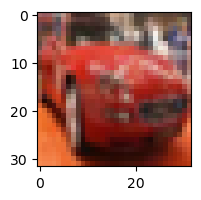

In [127]:
plot_sample(X_train, y_train, 5)

TypeError: only integer scalar arrays can be converted to a scalar index

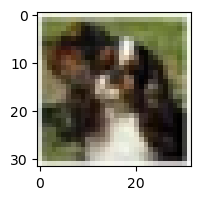

In [129]:
plot_sample(X_train, y_train, 500)

In [59]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [79]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


ann.fit(X_train, y_train, epochs=5)
    

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 74ms/step - accuracy: 0.3523 - loss: 1.8121
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.4273 - loss: 1.6255
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 110s 70ms/step - accuracy: 0.4572 - loss: 1.5423
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2269s 1s/step - accuracy: 0.4774 - loss: 1.4829
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.4946 - loss: 1.4351


In [83]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification report: \n',classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.55      0.55      0.55      1000
           1       0.53      0.71      0.60      1000
           2       0.33      0.46      0.39      1000
           3       0.37      0.28      0.32      1000
           4       0.55      0.21      0.31      1000
           5       0.38      0.44      0.41      1000
           6       0.56      0.50      0.52      1000
           7       0.58      0.52      0.55      1000
           8       0.61      0.63      0.62      1000
           9       0.50      0.58      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.48     10000
weighted avg       0.50      0.49      0.48     10000



In [85]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

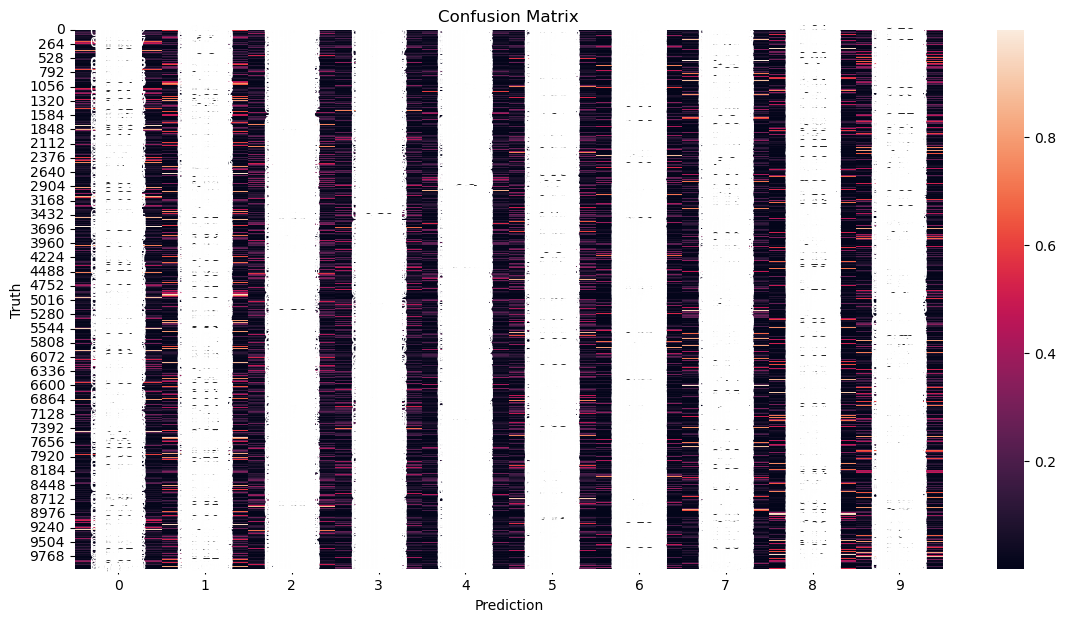

In [87]:
plt.figure(figsize = (14,7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show

In [105]:
cnn = models.Sequential([
    layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(32, 32, 3)
),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10,activation='softmax')

])    
    

In [111]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [113]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.4779 - loss: 1.4505
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6125 - loss: 1.1048
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.6574 - loss: 0.9787
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6884 - loss: 0.8931
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7097 - loss: 0.8286
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.7298 - loss: 0.7715
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.7458 - loss: 0.7277
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.7611 - loss: 0.6826
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7746 - loss: 0.6460
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.7868 - loss: 0.6101


In [115]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6987 - loss: 0.9244


[0.9244033098220825, 0.6987000107765198]

In [117]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[1.4433684e-02, 6.5034172e-03, 9.4975745e-03, 6.2859428e-01,
        9.1944734e-04, 2.5614145e-01, 1.7829146e-02, 2.8187831e-05,
        6.4428657e-02, 1.6241542e-03],
       [6.1108229e-05, 5.4487079e-01, 1.6679238e-07, 2.0526222e-07,
        9.1267980e-09, 1.3257952e-08, 1.8918897e-07, 7.7976176e-10,
        4.5487118e-01, 1.9633063e-04],
       [3.8347121e-02, 7.2602773e-01, 4.1359660e-04, 9.9369092e-04,
        1.0910936e-04, 1.9907789e-05, 7.2095188e-04, 2.0326859e-05,
        2.2829163e-01, 5.0559351e-03],
       [9.7666538e-01, 3.4467450e-03, 7.7192014e-04, 3.1118531e-04,
        4.0421812e-04, 3.2483183e-06, 2.7090576e-04, 1.9077077e-06,
        1.8030796e-02, 9.3667542e-05],
       [3.9124518e-07, 1.3817043e-05, 7.9078814e-03, 8.7083876e-03,
        2.8812721e-01, 2.3803639e-04, 6.9498223e-01, 1.9081702e-07,
        2.1300075e-05, 5.5866656e-07]], dtype=float32)

In [119]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 1, 1, 0, 6]

In [121]:
y_test[:]

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

TypeError: only integer scalar arrays can be converted to a scalar index

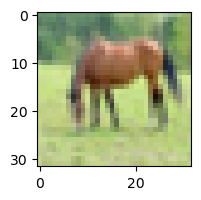

In [131]:
plot_sample(X_test, y_test, 60)

In [133]:
classes[y_classes[4]]

'frog'